Install MySQL package

In [5]:
!pip install mysql-connector-python


[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Import libraries

In [6]:
import pandas as pd
import mysql.connector
import getpass
import matplotlib.pyplot as plt

Connect to MySQL

In [7]:

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=getpass.getpass("Enter MySQL Password: "),
    database="milodrive"
)

print("Connected successfully!")

Connected successfully!


Read tables from xlsx file

In [8]:
file_path = "data/Exercise 1_Analytical Sample.xlsx"

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['trip_activity', 'payment_transactions', 'driver_activity']


In [9]:
trip = pd.read_excel(file_path, sheet_name="trip_activity", header=1)

payment = pd.read_excel(file_path, sheet_name="payment_transactions", header=1)

driver = pd.read_excel(file_path, sheet_name="driver_activity", header=1)

In [10]:
trip.head()

,Trip UUID,Driver UUID,Vehicle UUID,Number plate,Service type,Trip request time,Trip drop-off time,Trip distance,Trip status
0,33dc176e-36bd-4920-81b1-27ffdcbf9487,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,2024-08-07 23:13:00,2024-08-07 23:22:00,1.53,completed
1,78269b0a-2e66-45f6-b1e5-ea2c024f5f03,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,2024-08-07 22:35:00,2024-08-07 23:05:00,6.74,completed
2,b4ef3116-3905-442e-bfdd-98c6863e1df5,ecd990ea-f209-4d3b-aa30-2774860ed903,a3efa7ff-d842-41d1-93f1-db3c2a7155d7,MH46CL5035,personal_transport,2024-08-07 21:43:00,2024-08-07 22:34:00,11.86,completed
3,a403e7e2-99bc-49fc-84b0-0795dcaa1fee,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,2024-08-07 21:06:00,2024-08-07 22:06:00,41.80,completed
4,9f598db0-21c0-4bd3-ac7e-eeaa697cee2f,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,2024-08-07 20:49:00,2024-08-07 21:09:00,4.37,completed


In [11]:
payment.head()

,transaction UUID,Driver UUID,Trip UUID,Description,vs reporting,Paid to you,Paid to you : Your earnings,Paid to you : Trip balance : Payouts : Cash collected,Paid to you : Your earnings : Fare,Paid to you : Your earnings : Taxes,...,Paid to you:Your earnings:Fare:UberX Priority,Paid to you:Your earnings:Fare:Max Fare Adjustment,Paid to you:Your earnings:Fare:Wait Time at Pick-up,Paid to you:Your earnings:Fare:Package Fare,Paid to you:Your earnings:Fare:Additional time charges,Paid to you:Your earnings:Fare:Adjustment,Paid to you:Your earnings:Fare:Surge,Paid to you:Your earnings:Fare:Cancellation,Paid to you:Your earnings:Fare:Additional cancellation fee for extended wait time,Paid to you:Your earnings:Fare:Reservation Fee
0,5605e092-1935-3fd5-b866-7c04d69b83ba,100b888d-c025-49b3-814d-eb21f147c87c,18b4109a-7c54-493a-a34d-f4bd9d90c903,trip completed order,2024-08-01 15:57:50.582 +0530 IST,180.99,180.99,0.0,180.99,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43fae3fe-61d7-3df5-8a0b-ac57526a9b68,100b888d-c025-49b3-814d-eb21f147c87c,18b4109a-7c54-493a-a34d-f4bd9d90c903,trip fare adjust order,2024-08-01 15:57:52.498 +0530 IST,-1.81,-1.81,0.0,0.00,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,f9e6728c-608e-3f24-81d6-1eab0fac5060,100b888d-c025-49b3-814d-eb21f147c87c,31d425de-d5c0-47f9-910f-591fd667dcda,trip completed order,2024-08-01 16:16:49.894 +0530 IST,-47.17,108.83,-156.0,108.83,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6c267932-6219-341c-93d6-e6676b82f2c5,100b888d-c025-49b3-814d-eb21f147c87c,31d425de-d5c0-47f9-910f-591fd667dcda,trip fare adjust order,2024-08-01 16:16:51.466 +0530 IST,-1.09,-1.09,0.0,0.00,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4dd0c649-7087-34b8-82ec-e7c39f5e7d55,100b888d-c025-49b3-814d-eb21f147c87c,ae599d9a-53ae-4ceb-a9fe-9d057c7e63c8,trip completed order,2024-08-01 16:45:44.601 +0530 IST,158.59,158.59,0.0,158.59,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
driver.head()

,Driver UUID,Time online (days : hours: minutes),Time on trip (days : hours : minutes)
0,ecd990ea-f209-4d3b-aa30-2774860ed903,02:10:27,01:10:33
1,47234e95-0d39-458e-bd76-616a05603baf,01:15:37,00:09:54
2,100b888d-c025-49b3-814d-eb21f147c87c,03:07:57,02:02:17
3,9b62fc51-c0c2-4c38-8d6e-7d0f6d69f411,00:05:54,00:05:24
4,54bad470-c12e-45c5-8910-9559f03ea34b,02:09:40,01:16:09


In [13]:
trip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Trip UUID           183 non-null    object        
 1   Driver UUID         183 non-null    object        
 2   Vehicle UUID        183 non-null    object        
 3   Number plate        183 non-null    object        
 4   Service type        183 non-null    object        
 5   Trip request time   183 non-null    datetime64[ns]
 6   Trip drop-off time  153 non-null    datetime64[ns]
 7   Trip distance       183 non-null    float64       
 8   Trip status         183 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 13.0+ KB


In [14]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 25 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   transaction UUID                                                                   321 non-null    object 
 1   Driver UUID                                                                        321 non-null    object 
 2   Trip UUID                                                                          321 non-null    object 
 3   Description                                                                        321 non-null    object 
 4   vs reporting                                                                       321 non-null    object 
 5   Paid to you                                                                        321 non-null    float64

In [15]:
driver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Driver UUID                            5 non-null      object
 1   Time online (days : hours: minutes)    5 non-null      object
 2   Time on trip (days : hours : minutes)  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes


checking null values in table

In [16]:
trip.isnull().sum()

Trip UUID              0
Driver UUID            0
Vehicle UUID           0
Number plate           0
Service type           0
Trip request time      0
Trip drop-off time    30
Trip distance          0
Trip status            0
dtype: int64

In [17]:
payment.isnull().sum()

transaction UUID                                                                     0
Driver UUID                                                                          0
Trip UUID                                                                            0
Description                                                                          0
vs reporting                                                                         0
Paid to you                                                                          0
Paid to you : Your earnings                                                          0
Paid to you : Trip balance : Payouts : Cash collected                                0
Paid to you : Your earnings : Fare                                                   0
Paid to you : Your earnings : Taxes                                                  0
Paid to you:Your earnings:Fare:Fare                                                  0
Paid to you:Trip balance:Refunds:Toll      

In [18]:
driver.isnull().sum()

Driver UUID                              0
Time online (days : hours: minutes)      0
Time on trip (days : hours : minutes)    0
dtype: int64

checking duplicates in tables

In [19]:
trip.duplicated().sum()

0

In [20]:
payment.duplicated().sum()

0

In [21]:
driver.duplicated().sum()

0

viewing columns in table

In [22]:
trip.columns

Index(['Trip UUID', 'Driver UUID', 'Vehicle UUID', 'Number plate',
       'Service type', 'Trip request time', 'Trip drop-off time',
       'Trip distance', 'Trip status'],
      dtype='object')

In [23]:
payment.columns

Index(['transaction UUID', 'Driver UUID', 'Trip UUID', 'Description',
       'vs reporting', 'Paid to you', 'Paid to you : Your earnings',
       'Paid to you : Trip balance : Payouts : Cash collected',
       'Paid to you : Your earnings : Fare',
       'Paid to you : Your earnings : Taxes',
       'Paid to you:Your earnings:Fare:Fare',
       'Paid to you:Trip balance:Refunds:Toll',
       'Paid to you:Your earnings:Tip',
       'Paid to you:Your earnings:Taxes:Income tax withholding',
       'Paid to you:Your earnings:Fare:Booking fee',
       'Paid to you:Your earnings:Fare:UberX Priority',
       'Paid to you:Your earnings:Fare:Max Fare Adjustment',
       'Paid to you:Your earnings:Fare:Wait Time at Pick-up',
       'Paid to you:Your earnings:Fare:Package Fare',
       'Paid to you:Your earnings:Fare:Additional time charges',
       'Paid to you:Your earnings:Fare:Adjustment',
       'Paid to you:Your earnings:Fare:Surge',
       'Paid to you:Your earnings:Fare:Cancellation',
   

In [24]:
driver.columns

Index(['Driver UUID', 'Time online (days : hours: minutes)',
       'Time on trip (days : hours : minutes)'],
      dtype='object')

extracting updated tables from MySQL

In [25]:
trip = pd.read_sql("SELECT * FROM trip_activity", conn)
payment = pd.read_sql("SELECT * FROM payment_transactions", conn)
driver = pd.read_sql("SELECT * FROM driver_activity", conn)

conn.close()

C:\Users\Harsh\AppData\Local\Temp\ipykernel_43820\3218152882.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trip = pd.read_sql("SELECT * FROM trip_activity", conn)
C:\Users\Harsh\AppData\Local\Temp\ipykernel_43820\3218152882.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  payment = pd.read_sql("SELECT * FROM payment_transactions", conn)
C:\Users\Harsh\AppData\Local\Temp\ipykernel_43820\3218152882.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  driver = pd.read_sql("SELECT * FROM driver_activity", conn)


In [26]:
trip.head()

,trip_uuid,driver_uuid,vehicle_uuid,number_plate,service_type,trip_request_time,trip_dropoff_time,trip_distance,trip_status,request_time,dropoff_time
0,33dc176e-36bd-4920-81b1-27ffdcbf9487,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 23:13,07/08/24 23:22,1.53,completed,2024-08-07 23:13:00,2024-08-07 23:22:00
1,78269b0a-2e66-45f6-b1e5-ea2c024f5f03,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 22:35,07/08/24 23:05,6.74,completed,2024-08-07 22:35:00,2024-08-07 23:05:00
2,b4ef3116-3905-442e-bfdd-98c6863e1df5,ecd990ea-f209-4d3b-aa30-2774860ed903,a3efa7ff-d842-41d1-93f1-db3c2a7155d7,MH46CL5035,personal_transport,07/08/24 21:43,07/08/24 22:34,11.86,completed,2024-08-07 21:43:00,2024-08-07 22:34:00
3,a403e7e2-99bc-49fc-84b0-0795dcaa1fee,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 21:06,07/08/24 22:06,41.80,completed,2024-08-07 21:06:00,2024-08-07 22:06:00
4,9f598db0-21c0-4bd3-ac7e-eeaa697cee2f,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 20:49,07/08/24 21:09,4.37,completed,2024-08-07 20:49:00,2024-08-07 21:09:00


In [27]:
payment.head()

,transaction_uuid,driver_uuid,trip_uuid,description,vs_reporting,paid_to_you,paid_to_you_your_earnings,paid_to_you_trip_balance_payouts_cash_collected,paid_to_you_your_earnings_fare,paid_to_you_your_earnings_taxes,...,paid_to_you_your_earnings_fare_uberx_priority,paid_to_you_your_earnings_fare_max_fare_adjustment,paid_to_you_your_earnings_fare_wait_time_at_pickup,paid_to_you_your_earnings_fare_package_fare,paid_to_you_your_earnings_fare_additional_time_charges,paid_to_you_your_earnings_fare_adjustment,paid_to_you_your_earnings_fare_surge,paid_to_you_your_earnings_fare_cancellation,paid_to_you_your_earnings_fare_additional_cancellation_fee,paid_to_you_your_earnings_fare_reservation_fee
0,5605e092-1935-3fd5-b866-7c04d69b83ba,100b888d-c025-49b3-814d-eb21f147c87c,18b4109a-7c54-493a-a34d-f4bd9d90c903,trip completed order,2024-08-01 15:57:50.582 +0530 IST,180.99,180.99,0.0,180.99,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43fae3fe-61d7-3df5-8a0b-ac57526a9b68,100b888d-c025-49b3-814d-eb21f147c87c,18b4109a-7c54-493a-a34d-f4bd9d90c903,trip fare adjust order,2024-08-01 15:57:52.498 +0530 IST,-1.81,-1.81,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,f9e6728c-608e-3f24-81d6-1eab0fac5060,100b888d-c025-49b3-814d-eb21f147c87c,31d425de-d5c0-47f9-910f-591fd667dcda,trip completed order,2024-08-01 16:16:49.894 +0530 IST,-47.17,108.83,-156.0,108.83,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6c267932-6219-341c-93d6-e6676b82f2c5,100b888d-c025-49b3-814d-eb21f147c87c,31d425de-d5c0-47f9-910f-591fd667dcda,trip fare adjust order,2024-08-01 16:16:51.466 +0530 IST,-1.09,-1.09,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4dd0c649-7087-34b8-82ec-e7c39f5e7d55,100b888d-c025-49b3-814d-eb21f147c87c,ae599d9a-53ae-4ceb-a9fe-9d057c7e63c8,trip completed order,2024-08-01 16:45:44.601 +0530 IST,158.59,158.59,0.0,158.59,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
driver.head()

,driver_uuid,time_online,time_on_trip
0,100b888d-c025-49b3-814d-eb21f147c87c,0 days 03:07:57,0 days 02:02:17
1,47234e95-0d39-458e-bd76-616a05603baf,0 days 01:15:37,0 days 00:09:54
2,54bad470-c12e-45c5-8910-9559f03ea34b,0 days 02:09:40,0 days 01:16:09
3,9b62fc51-c0c2-4c38-8d6e-7d0f6d69f411,0 days 00:05:54,0 days 00:05:24
4,ecd990ea-f209-4d3b-aa30-2774860ed903,0 days 02:10:27,0 days 01:10:33


In [29]:
trip["request_time"] = pd.to_datetime(trip["request_time"])

trip["dropoff_time"] = pd.to_datetime(trip["dropoff_time"])

In [30]:
driver["time_online"] = pd.to_timedelta(driver["time_online"])

driver["time_on_trip"] = pd.to_timedelta(driver["time_on_trip"])

In [31]:
payment_summary = payment.groupby(
    ["trip_uuid", "driver_uuid"],
    as_index=False
)["paid_to_you_your_earnings"].sum()

Merging tables

In [32]:
df = trip.merge(
    payment_summary,
    on=["trip_uuid", "driver_uuid"],
    how="left"
)

In [33]:
df = df.merge(
    driver,
    on="driver_uuid",
    how="left"
)

In [34]:
df.head()

,trip_uuid,driver_uuid,vehicle_uuid,number_plate,service_type,trip_request_time,trip_dropoff_time,trip_distance,trip_status,request_time,dropoff_time,paid_to_you_your_earnings,time_online,time_on_trip
0,33dc176e-36bd-4920-81b1-27ffdcbf9487,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 23:13,07/08/24 23:22,1.53,completed,2024-08-07 23:13:00,2024-08-07 23:22:00,132.01,0 days 03:07:57,0 days 02:02:17
1,78269b0a-2e66-45f6-b1e5-ea2c024f5f03,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 22:35,07/08/24 23:05,6.74,completed,2024-08-07 22:35:00,2024-08-07 23:05:00,132.41,0 days 03:07:57,0 days 02:02:17
2,b4ef3116-3905-442e-bfdd-98c6863e1df5,ecd990ea-f209-4d3b-aa30-2774860ed903,a3efa7ff-d842-41d1-93f1-db3c2a7155d7,MH46CL5035,personal_transport,07/08/24 21:43,07/08/24 22:34,11.86,completed,2024-08-07 21:43:00,2024-08-07 22:34:00,249.27,0 days 02:10:27,0 days 01:10:33
3,a403e7e2-99bc-49fc-84b0-0795dcaa1fee,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 21:06,07/08/24 22:06,41.80,completed,2024-08-07 21:06:00,2024-08-07 22:06:00,553.17,0 days 03:07:57,0 days 02:02:17
4,9f598db0-21c0-4bd3-ac7e-eeaa697cee2f,100b888d-c025-49b3-814d-eb21f147c87c,8702d75f-7996-4e9d-98c9-3604d41d0c0d,MH46CL4291,personal_transport,07/08/24 20:49,07/08/24 21:09,4.37,completed,2024-08-07 20:49:00,2024-08-07 21:09:00,150.05,0 days 03:07:57,0 days 02:02:17


Driver summary

In [35]:
driver_summary = df.groupby("driver_uuid").agg(

    total_trips=("trip_uuid","count"),

    completed_trips=("trip_status",
                     lambda x:(x=="completed").sum()),

    total_earnings=("paid_to_you_your_earnings","sum"),

    average_trip_value=("paid_to_you_your_earnings","mean"),

    total_distance=("trip_distance","sum")

).reset_index()

In [36]:
driver_summary["completion_rate"] = (
    driver_summary["completed_trips"]
    / driver_summary["total_trips"]
    *100
)

In [37]:
utilisation = driver.copy()

utilisation["utilisation"] = (
    utilisation["time_on_trip"]
    /
    utilisation["time_online"]
)*100

In [38]:
driver_summary = driver_summary.merge(

    utilisation[
        ["driver_uuid","utilisation"]
    ],

    on="driver_uuid"
)

Daily summary

In [39]:
df["date"] = df["request_time"].dt.date

In [40]:
daily_summary = df.groupby(
    ["driver_uuid","date"]
).agg(

    trips=("trip_uuid","count"),

    earnings=("paid_to_you_your_earnings","sum"),

    distance=("trip_distance","sum")

).reset_index()

bar Charts

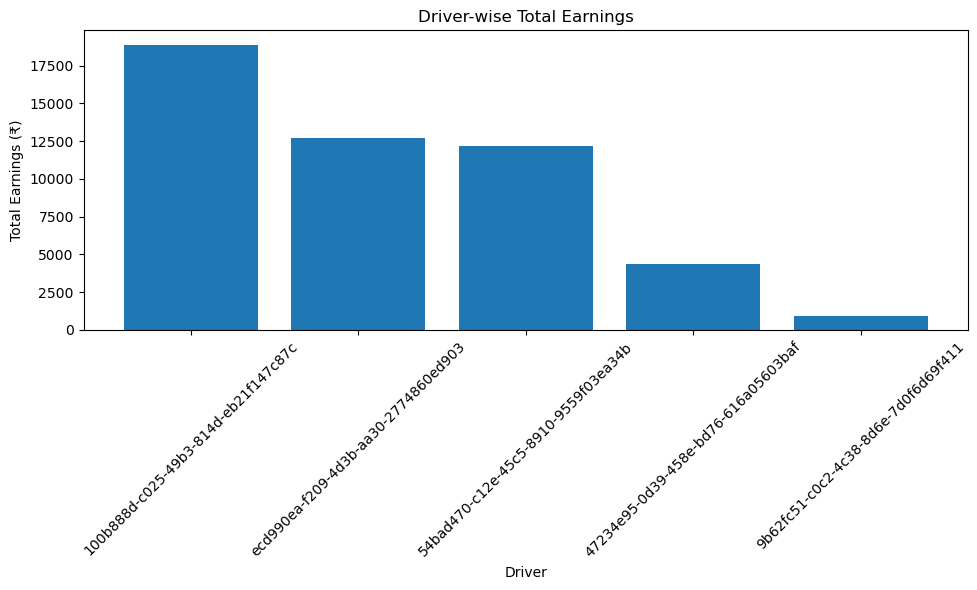

In [43]:
driver_summary = df.groupby("driver_uuid").agg(
    total_trips=("trip_uuid","count"),
    total_earnings=("paid_to_you_your_earnings","sum"),
    total_distance=("trip_distance","sum")
).reset_index()

driver_summary = driver_summary.sort_values(
    "total_earnings",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    driver_summary["driver_uuid"],
    driver_summary["total_earnings"]
)

plt.xticks(rotation=45)
plt.xlabel("Driver")
plt.ylabel("Total Earnings (₹)")
plt.title("Driver-wise Total Earnings")

plt.tight_layout()
plt.show()

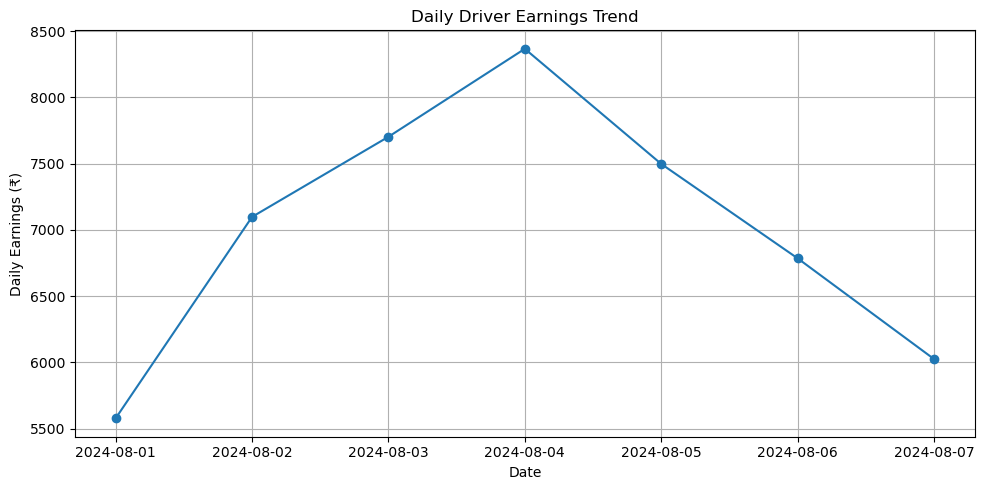

In [44]:
df["date"] = pd.to_datetime(df["request_time"]).dt.date

daily = df.groupby("date")["paid_to_you_your_earnings"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    daily.index,
    daily.values,
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Daily Earnings (₹)")
plt.title("Daily Driver Earnings Trend")

plt.grid(True)

plt.tight_layout()

plt.show()

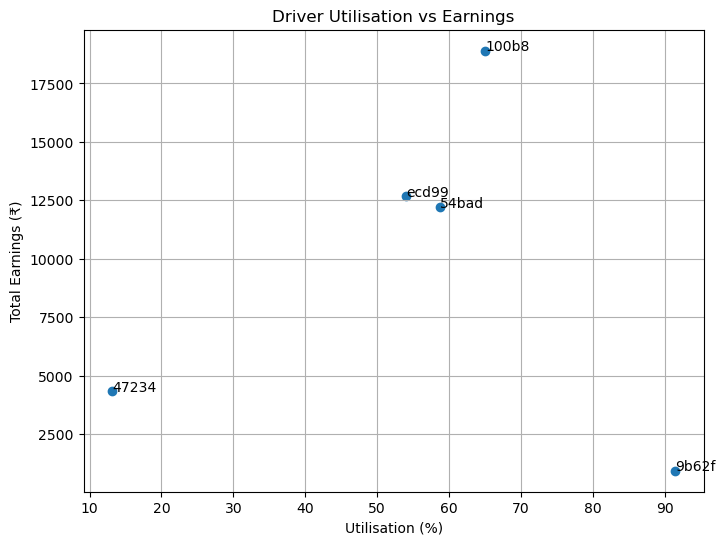

In [45]:
driver_summary = driver_summary.merge(
    driver,
    on="driver_uuid"
)

driver_summary["utilisation"] = (
    pd.to_timedelta(driver_summary["time_on_trip"]).dt.total_seconds()
    /
    pd.to_timedelta(driver_summary["time_online"]).dt.total_seconds()
)*100

plt.figure(figsize=(8,6))

plt.scatter(
    driver_summary["utilisation"],
    driver_summary["total_earnings"]
)

for i,row in driver_summary.iterrows():
    plt.text(
        row["utilisation"],
        row["total_earnings"],
        row["driver_uuid"][:5]
    )

plt.xlabel("Utilisation (%)")
plt.ylabel("Total Earnings (₹)")
plt.title("Driver Utilisation vs Earnings")

plt.grid(True)

plt.show()

# Findings